# Weak Supervision


## Introduction

The idea behind **weak supervision** is that for each data point there is a *latent true label* that is inaccessible to us even during training, instead we utilize weak signals from user-defined **labeling functions** (LF). The material here is based on the **data programming** approach to weak supervision using LFs described in [@data-programming]. Here we extend to the multi-class case where the generative model has entries of the entire confusion matrix as learnable parameters.

LFs can be thought of as heuristic rules that can be applied to a large subset of the data. In case the LF is not applicable, then the function simply abstains from making a prediction. Note that this is a realistic scenario, it's easier to describe rules than to manually annotate a large number of data points. LFs provide noisy, but potentially cost-effective labels, which can be used to train discriminative models. 

![**Weak supervision training pipeline**. The third image is flipped (i.e. the flow of prediction is right to left.) 
These two tasks will be implemented in this notebook. [Source](https://cs.brown.edu/people/sbach/files/bach-icml17-slides.pdf)](./img/01-weak-supervision-pipeline.png)

### Labeling Functions

Suppose we have a large corpus of IMDB movie reviews that we want to classify as positive or negative. Manually labeling thousands of reviews is expensive, but we can write heuristic rules called **labeling functions** (LF) that capture common patterns. Each LF inspects a review and returns `+1` (positive), `-1` (negative), or `0` (abstain). 

To demonstrate examples of LFs, we load the [IMDB Movie Reviews dataset](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews):

In [1]:
#| output: false
import re
import numpy as np
import torch
import pandas as pd
from datasets import load_dataset

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)

ds = load_dataset("imdb")
ds_train = ds["train"].shuffle(seed=RANDOM_SEED).select(range(3000))
train_texts = ds_train["text"]
y_train_imdb = np.array(ds_train["label"])  # {0, 1}

K = 2
ABSTAIN = -1

Sample IMDB movie review from the dataset:

In [2]:
#| code-fold: true
from IPython.display import display, Markdown

print(y_train_imdb[0])
display(Markdown('> ' + train_texts[0]))

1


> We always watch American movies with their particular accents from each region (south, west, etc). We have the same here. All foreign people must to watch this movie and need to have a open mind to accept another culture, besides American and European almost dominate the cinematographic industry.<br /><br />This movie tell us about a parallel world which it isn't figured even for those who live in a big city like São Paulo. All actors are improvising and they are very realistic. The camera give us an idea of their confuse world, the loneliness of each character and invite us to share their world.<br /><br />It's a real great movie and worst a rent even have it at home.

LFs can exploit many kinds of signals. Here we consider word counts, explicit ratings, viewing behavior, or comparative language:

In [3]:
def lf_sentiment_words(text):
    text = text.lower()
    pos_count = sum(1 for w in ["great", "love", "amazing", "fun"] if w in text)
    neg_count = sum(1 for w in ["bad", "waste", "boring", "stupid"] if w in text)
    if pos_count > neg_count: return 1
    if neg_count > pos_count: return 0
    return ABSTAIN

def lf_viewing_experience(text):
    text_lower = text.lower()
    pos_watch = ["watched twice", "watch again", "rewatch", "couldn't stop watching"]
    neg_watch = ["walked out", "turned it off", "fell asleep", "couldn't finish"]
    pos = any(p in text_lower for p in pos_watch)
    neg = any(n in text_lower for n in neg_watch)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN

def lf_comparative_sentiment(text):
    text_lower = text.lower()
    if "worse than" in text_lower or "not as good as" in text_lower:
        return 0
    return ABSTAIN

Consider these example reviews and notice how each LF can be fooled or simply silent:

In [4]:
review = "I've watched this twice already and couldn't stop watching — the pacing is superb."

print(f"lf_sentiment_words        {str(lf_sentiment_words(review)):>2s}")          # abstain: no lexicon words match
print(f"lf_viewing_experience     {str(lf_viewing_experience(review)):>2s}")       # "couldn't stop watching" phrase present
print(f"lf_comparative_sentiment  {str(lf_comparative_sentiment(review)):>2s}")    # abstain: no comparative phrases match

lf_sentiment_words        -1
lf_viewing_experience      1
lf_comparative_sentiment  -1


The ff. shows an issue with keyword matching where sense of negation is not captured  (e.g. double negative):

In [5]:
review = "It's ok, not amazing but not worse than anything I've seen this year."

print(f"lf_sentiment_words        {str(lf_sentiment_words(review)):>2s}")          # captures "amazing" even when negated
print(f"lf_viewing_experience     {str(lf_viewing_experience(review)):>2s}")       # abstain: no viewing experience phrase present
print(f"lf_comparative_sentiment  {str(lf_comparative_sentiment(review)):>2s}")    # negative: "worse than" even if negated

lf_sentiment_words         1
lf_viewing_experience     -1
lf_comparative_sentiment   0


All abstain despite clear negative:

In [6]:
review = """
This movie is an absolute DISASTER. Two hours of my life I'll never get back.
The plot makes zero sense, the acting is wooden, and the dialogue sounds like
it was written by a toddler. Every scene drags on forever. I've seen better
cinematography in a high school project. The sound mixing is atrocious. Zero stars.
"""

print(f"lf_sentiment_words        {str(lf_sentiment_words(review)):>2s}")
print(f"lf_viewing_experience     {str(lf_viewing_experience(review)):>2s}")
print(f"lf_comparative_sentiment  {str(lf_comparative_sentiment(review)):>2s}")

lf_sentiment_words        -1
lf_viewing_experience     -1
lf_comparative_sentiment  -1


:::{.callout-tip}
LFs are  **iteratively refined** in practice: we inspect disagreements between LFs, compare against any available ground truth, and consult domain knowledge. Since LFs are user-defined heuristics, they require some expertise and data exploration to be effective. This requires substantial effort and (from experience) can even be scoped as one project under a team of annotators.

Since human annotation and cross-checking multiple LF outputs is prohibitive, LLMs can also serve as LFs: instead of hand-writing heuristics, you prompt a model to generate heuristics for a labeling function. This is a form of **knowledge distillation**: [the LLM's broad world knowledge gets compressed into a smaller, faster model via the weak supervision pipeline]{.mark} rather than through soft targets directly. At the very extreme, an LLM itself can directly be an LF[^llm_funcs]:

```python
def lf_llm(text):
    # can engineer abstention tendency by prompting
    response = client.chat.completions.create(...)
    return 1 if "positive" in response else 0 if "negative" in response else ABSTAIN
```

The [generative model](/notebooks/tooling/10-weak-supervision.html#basic-theory) (discussed below) still earns its keep here, since LLM-based LFs can have systematic biases that confusion matrix estimation helps correct. Cost efficiency is the main motivation: pay for LLM inference on a small subset, then train on the full dataset using the resulting noisy labels. This can be more cost-effective over performing LLM inference at scale. Moreover, multiple LFs can be created from a single LLM by varying the prompt — different phrasings, chain-of-thought vs. few-shot, and so on, giving the model more signal to work with.
:::

[^llm_funcs]: See [Text-to-LoRA](https://arxiv.org/abs/2506.06105). Also the [ProgramAsWeights](https://programasweights.readthedocs.io/en/latest/) project which compiles an LLM into task-specific runnable local functions.

### LF parameters

A labeling function is characterized by its **coverage** (fraction of inputs where it does not abstain) and its **F1 score** on non-abstaining inputs. For the IMDB task, a full set of seven LFs has the following profile:

| LF | Coverage | F1 |
| :-: | :-: | :-: |
| `lf_strong_sentiment` | 0.41 | 0.881 |
| `lf_sentiment_words` | 0.69 | 0.746 |
| `lf_rating_mention` | 0.02 | 0.812 |
| `lf_viewing_experience` | 0.01 | 0.800 |
| `lf_comparative_sentiment` | 0.01 | 0.711 |
| `lf_recommendation` | 0.11 | 0.798 |
| `lf_exclamation_sentiment` | 0.05 | 0.811 |

[There is a natural trade-off:]{.underline} LFs with broad coverage (like `lf_sentiment_words`) tend to have lower F1, while high-F1 LFs fire on fewer reviews (`lf_strong_sentiment` is a notable exception). The full definitions of these LFs and their application to IMDB data appear in the [application section](#application-imdb-movie-reviews) at the end of this notebook.

:::{.callout-note}
We generally do not have access to true labels for a representative sample of our dataset (or at best have access to a small labeled subset). Hence, even estimating the accuracy and coverage of our LFs is not possible. The following sections will deal with algorithms for estimating these parameters as well as training a machine learning model with noisy labels.
:::

In practice, the generative model performs at roughly the F1 of the best LFs, modulated by their coverage. The ideal scenario is a set of **conditionally independent** LFs — ones that fire on different subsets of the data and make mistakes on different examples. In that case, the generative model can ensemble them toward higher F1 than any single LF alone, since other LFs compensate for the gaps of one.

## Basic theory


For simplicity, we will limit our presentation to binary classification, although the method extends to the multiclass setting. For each data point $\textbf{\textsf{x}} \in \mathcal{X},$ the latent true label is $y \in \mathcal{Y} = \{0, 1, \ldots, K-1\}$. Suppose we have $N$ **labeling functions** $\lambda_j\colon \mathcal{X} \to \mathcal{Y} \cup \{-1\},$ where $-1$ denotes **abstention**. Given $M$ data points $\textbf{\textsf{x}}_i,$ we obtain an $M \times N$ matrix of LF outputs $\Lambda_{ij} = \lambda_j(\textbf{\textsf{x}}_i)$.

We write $\Lambda$ for the random variable representing LF outputs and $\lambda(\textbf{\textsf{x}})$ for the realized output vector of a specific input. Our first step is to estimate the joint distribution $p_\Phi(\lambda, y)$ as well as the marginal $p_\Phi(\Lambda) = \prod_{i=1}^M p(\lambda(\textbf{\textsf{x}}_i)).$ We do MLE to find parameters $\hat{\Phi}$ that maximize the log-likelihood of the marginal 
$p_\Phi(\Lambda)$ of the observed LF outputs. See [below](/notebooks/tooling/10-weak-supervision.html#generative-model). This lets us calculate[^bayes]:

$$
\boxed{
    p_{\hat{\Phi}}(y \mid  \lambda(\textbf{\textsf{x}})) = \frac{p_{\hat{\Phi}}( y,\,  \lambda(\textbf{\textsf{x}}))}{p_{\hat{\Phi}}( \lambda(\textbf{\textsf{x}}))} = \frac{p_{\hat{\Phi}}( \lambda(\textbf{\textsf{x}}) \mid y)\, p_y}{\sum_{y'=0}^{K-1} p_{\hat{\Phi}}(\lambda(\textbf{\textsf{x}}) \mid y')\, p_{y'}}
}
$$ 

for any $y = 0, \ldots, K-1$ and any input $\textbf{\textsf{x}}.$ Given this, we perform **noise-aware training** (NAT) of a classifier $f_\Theta$ by minimizing the following loss:

$$
\boxed{
    \mathcal{L}_{\text{clf}}(\Theta) = 
    \frac{1}{M}\sum_{i=1}^M \sum_{y=0}^{K-1} 
    \ell(f_\Theta(\textbf{\textsf{x}}_i), y) \cdot 
    {p_{\hat{\Phi}}(y \mid  \lambda(\textbf{\textsf{x}}_i))}
}
$$

where $\ell$ is the usual loss criterion. This looks like the usual loss, except we don't have a single label. All labels contribute weighted by the probability of the label given the LF outputs of the input.

[^bayes]: While we need $p_{\hat{\Phi}}(y \mid  \lambda(\textbf{\textsf{x}}))$ for training, what we have access to is the reverse: $p_{\hat{\Phi}}(\lambda(\textbf{\textsf{x}}) \mid y)$ which we estimate by performing MLE on the LF outputs based on *all* targets (since we don't know which is the real one).

:::{.callout-note}
Each combination of $N$ LF outputs defines one of $3^N$ patterns, and the generative model assigns the same soft label to all points sharing a pattern. Exponential growth helps: 7 LFs yield $3^7 = 2{,}187$ bins. So this discretizes the space, and we rely on the hypothesis that points in the same bin share a label distribution for sufficiently large $N$ (which we hope to be not too large).
:::

### Generative model

Each LF has its own [confusion matrix](https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html) showing how its outputs relate to the true labels. For instance, `lf_sentiment_words` has asymmetric accuracy — it is much better at identifying positive reviews than negative ones:

In [7]:
from sklearn.metrics import confusion_matrix as cm

out = np.array([lf_sentiment_words(t) for t in train_texts])
F = out != ABSTAIN
label = y_train_imdb[F]
preds = out[F]

conf = cm(label, preds, labels=[0, 1])
df = pd.DataFrame(conf, index=["y=0 (neg)", "y=1 (pos)"], columns=["pred=0", "pred=1"])
df["abstain"] = [sum(y_train_imdb[~F] == 0).item(), sum(y_train_imdb[~F] == 1).item()]
df

,pred=0,pred=1,abstain
y=0 (neg),485,387,636
y=1 (pos),76,875,541


Observe that this can be converted to conditional probabilities given $y.$ Let's call the resulting matrix $\mathbf{C}^{(j)} \in [0, 1]^{K \times (K + 1)}$:

In [8]:
df / df.sum(axis=1).values.reshape(-1, 1)

,pred=0,pred=1,abstain
y=0 (neg),0.321618,0.256631,0.421751
y=1 (pos),0.050938,0.586461,0.362601


[This is precisely what the generative model will learn from input data.]{.mark} To see this, consider an input $\textbf{\textsf{x}}$, we get LF outputs $\lambda(\textbf{\textsf{x}}) \in [-1, 0, \ldots, K-1]^N.$ The marginal probability of this output vector is then:

$$
\boxed{p(\lambda(\textbf{\textsf{x}}) ) = \sum_y  p_{y} \cdot p_{{\Phi}}(\lambda(\textbf{\textsf{x}}) \mid y) = \sum_{y} p_y \cdot \prod_j C^j_{y, \lambda_j}}.
$$

Here we have to provide the **prior distribution** since the labels are censored. Also, we assume that the LF outputs are [conditionally independent]{.underline} given the true label. Note that the rows of $\mathbf{C}^{j}$ sum to 1, so our network will have logits of shape $K \times (K + 1)$ with entries ranging over $\mathbb{R}$; we will later apply softmax later along the rows. Finally, our goal is to perform MLE on $\Phi = \{\mathbf{C}^1, \ldots, \mathbf{C}^N\}$ by minimizing over the dataset:

$$
\boxed{
    \mathcal{L}_{\text{gen}}(\Phi) = \frac{1}{M}\sum_{i=1}^M -\log \left( 
        \sum_{y=0}^{K-1} p_y \cdot \prod_{j=1}^N C^j_{y,\, \Lambda_{ij}} 
    \right)
}.
$$


:::{.callout-note}
**Why model $p(\Lambda \mid Y)$ rather than $p(Y \mid \Lambda)$ directly?** Because the forward direction &mdash; how each LF behaves given a true label &mdash; is what we can decompose per-LF and estimate from unlabeled data. Each LF has its own confusion matrix independent of the others. Bayes' rule then gives us the posterior we actually need.
:::

:::{.callout-tip}
In practice, to avoid underflow with large number of LFs, we implement this using the $\text{LogSumExp}$ trick (e.g. with [`torch.logsumexp`](https://docs.pytorch.org/docs/stable/generated/torch.logsumexp.html)) as:

$$
{\log p(\lambda(\textbf{\textsf{x}})) = \log \sum_y \exp\!\left(\log p_y + \sum_j \log C^j_{y,\,\lambda_j}\right)}
$$

so that

$$
{
    \mathcal{L}_{\text{gen}}(\Phi) = -\frac{1}{M}\sum_{i=1}^M \log \sum_{y=0}^{K-1} \exp\!\left(\log p_y + \sum_{j=1}^N \log C^j_{y,\,\Lambda_{ij}}\right)
}.
$$

Finally, the soft target probability is given by:

$$
{
    p_{\hat{\Phi}}(y \mid \lambda(\textbf{\textsf{x}})) = \exp\Bigg(\log p_y + \sum_j \log C^j_{y,\,\lambda_j} - \log \sum_{y'} \exp\!\left(\log p_{y'} + \sum_j \log C^j_{y',\,\lambda_j}\right)\Bigg).
}
$$
:::

### Code implementation

For convenience, we let the elements of $\mathbf{C}^j$ be real numbers. Then, for each $j$, the confusion confusion matrix of the LF is obtained by taking the softmax along `dim=1` (i.e. conditioned on the target which is indexed in `dim=0`). We stack these along the third dimension so that we get a tensor $\mathbf{C}$ of shape $(K, K + 1, N).$ Since softmax is shift-invariant, we can initialize the abstain logits as $C_{y, K} = 0$ for all $y$, and derive its value from  non-abstain logits. This also makes it explicit that we have $K$ free parameters along a row.

In [9]:
import torch
torch.manual_seed(1)

K = 2
n = 4

# C[y, k, j] := P(λ_j = k | Y = y)
# C_logits is the unnormalized log-probs, which we optimize with gradient descent.
C_logits = torch.randn(K, K + 1, n)
C_logits[:, -1, :] = 0
C = torch.softmax(C_logits, dim=1)

print("Confusion matrix shape:", C.shape)
print(C)
print(C.sum(dim=1).numpy().sum())   # ~8 (2 targets x 4 LFs)

Confusion matrix shape: torch.Size([2, 3, 4])
tensor([[[0.1025, 0.2342, 0.2743, 0.1428],
         [0.4263, 0.2697, 0.1981, 0.1429],
         [0.4712, 0.4960, 0.5276, 0.7143]],

        [[0.4422, 0.0792, 0.2385, 0.1015],
         [0.1731, 0.5370, 0.4328, 0.7616],
         [0.3847, 0.3838, 0.3287, 0.1369]]])
8.0


We index into the confusion matrix using the LF output matrix. Class labels $\{0, \ldots, K-1\}$ map to the first $K$ columns, and abstain ($K$) maps to the last column. No remapping needed:

In [10]:
# Example LF output matrix: values in {0, 1, ..., K} where K = abstain
L = torch.tensor([
    [0, K,  1,  1],
    [1, 0,  0,  K],
])

# P(L | y=1): for each instance i and LF j, look up C[y=1, L[i,j], j]
y = 1
C[y, L, torch.arange(n)]  # shape: (m, n)

tensor([[0.4422, 0.3838, 0.4328, 0.7616],
        [0.1731, 0.0792, 0.2385, 0.1369]])

The product across LFs gives the conditional likelihood of the observed LF outputs for a given true label:

In [11]:
# P(Λ_i | y) = prod_j C[y, Λ_{ij}, j]
for y in range(K):
    probs = C[y, L, torch.arange(n)]  # (m, n)
    print(f"P(Λ | y={y}):", probs.prod(dim=1))

P(Λ | y=0): tensor([0.0014, 0.0196])
P(Λ | y=1): tensor([0.0560, 0.0004])


The marginal probability of the two LF outputs over the latent label:

In [12]:
py = torch.tensor([0.5, 0.5])  # class prior

p_marginal = sum(
    py[y] * C[y, L, torch.arange(n)].prod(dim=1)
    for y in range(K)
)

print("P([Λ0, Λ1]):", p_marginal)

P([Λ0, Λ1]): tensor([0.0287, 0.0100])


Finally, the marginal probability of the sample $p_{\Phi}(\Lambda).$ Because we generally have $M \gg 1$ terms with values in $[0, 1]$, we use $\log$ to avoid underflow:

In [13]:
print("     p(Λ):", p_marginal.prod().item())
print("-log p(Λ):", -torch.log(p_marginal).sum().item())

     p(Λ): 0.00028718687826767564
-log p(Λ): 8.155377388000488


## Toy experiments

In [14]:
#| output: false
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import random
import numpy as np
import pandas as pd

from notebooks.plot import set_format
set_format("svg")

RANDOM_SEED = 0
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

### Simulated LFs

Generating a toy dataset. Also setting the prior label probabilities:

In [15]:
m = 10000
K = 2
LABEL_PROBS = {0: 0.40, 1: 0.60}
y_true = np.random.choice([0, 1], size=m, p=[LABEL_PROBS[0], LABEL_PROBS[1]])

s = 2 * torch.pi * torch.rand(m, 1)
r = 0.5 * torch.tensor(y_true, dtype=torch.float32).view(-1, 1)  # 0 -> r=0, 1 -> r=0.5
x = torch.cat([r * torch.cos(s), r * torch.sin(s)], dim=1) + 0.05 * torch.randn(m, 2)

t = np.linspace(0, 2*np.pi, 100)
x0 = 0.5 * np.cos(t)
x1 = 0.5 * np.sin(t)
x_neg = x[torch.where(torch.tensor(y_true) == 0)]
x_pos = x[torch.where(torch.tensor(y_true) == 1)]

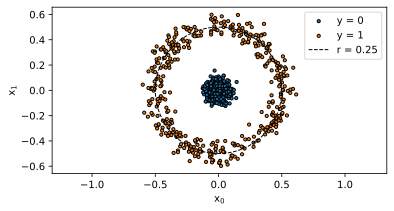

In [16]:
#| code-fold: true
def plot_dataset(x_neg, x_pos):
    m = len(x_neg)
    limit = m // 10
    plt.figure(figsize=(6, 3))
    plt.scatter(x_neg[:limit, 0], x_neg[:limit, 1], s=10.0, edgecolor="k", color="C0", label="y = 0")
    plt.scatter(x_pos[:limit, 0], x_pos[:limit, 1], s=10.0, edgecolor="k", color="C1", label="y = 1")
    plt.plot(x0, x1, color='black', linewidth=1, linestyle='dashed', label="r = 0.25")
    plt.xlabel("x$_0$")
    plt.ylabel("x$_1$")
    plt.legend()
    plt.axis("equal")

plot_dataset(x_neg, x_pos)

**Figure.** Below we use $r = 0.25$ as basis for synthetic LFs.

Note that radius less than 0.25 determines the label as $y = 0$ (with high probability):

In [17]:
# radius >= 0.25 -> class 1, else class 0
((torch.sqrt((x ** 2).sum(dim=1)) >= 0.25).long().numpy() == y_true).mean()

np.float64(1.0)

We use this to write simulated LFs with given parameters:

In [18]:
def lf_sim(coverage, accuracy):
    def predict(x):
        m = x.shape[0]
        y = (torch.sqrt((x ** 2).sum(dim=1)) >= 0.25).long()  # 0 or 1
        abstain_mask = torch.rand(m) >= coverage
        flip_mask = torch.rand(m) >= accuracy
        y[flip_mask] = 1 - y[flip_mask]         # flip label
        y[abstain_mask] = ABSTAIN               # -1
        return y
    return predict

# example
p = lf_sim(0.3, 0.8)(x).numpy()
fired = p != ABSTAIN
print("cov: ", fired.mean())
print("acc: ", (p[fired] == y_true[fired]).mean())
print("acc (y=0):", (p[fired & (y_true == 0)] == y_true[fired & (y_true == 0)]).mean())
print("acc (y=1):", (p[fired & (y_true == 1)] == y_true[fired & (y_true == 1)]).mean())

cov:  0.2993
acc:  0.7945205479452054
acc (y=0): 0.7960848287112561
acc (y=1): 0.7934352009054896


Initializing the empirical LF matrix for display. Some LFs have fairly low F1 on their covered examples:

In [19]:
lf_params = [(0.30, 0.75), (0.50, 0.65), (0.40, 0.70), (0.20, 0.80), (0.25, 0.90)]
labeling_funcs = [lf_sim(*param) for param in lf_params]

df = pd.DataFrame({"y": y_true})
df["x0"] = x[:, 0].numpy()
df["x1"] = x[:, 1].numpy()
for j, lf in enumerate(labeling_funcs):
    df[f"LF{j + 1}"] = lf(x).int().numpy()

print(df.shape)
df.head()

(10000, 8)


,y,x0,x1,LF1,LF2,LF3,LF4,LF5
0,1,-0.599245,0.044822,-1,1,-1,-1,-1
1,1,0.045224,-0.489432,-1,-1,0,-1,-1
2,1,0.367845,0.195856,-1,1,0,1,-1
3,1,0.345199,0.440180,-1,-1,-1,-1,-1
4,1,-0.138734,0.433529,1,1,-1,-1,-1


**Data split and LF matrix.** We split the data 80-20 for evaluation and precompute the LF output matrix $\Lambda$ for each split. Since `lf_sim` is stochastic (each call generates a fresh random sample), we call each LF once per split and store the results:

In [20]:
# 80-20
SPLIT_RATIO = 0.80
m = x.shape[0]
x_train = x[:int(SPLIT_RATIO * m)]
x_valid = x[int(SPLIT_RATIO * m):]
y_train = torch.tensor(y_true[:int(SPLIT_RATIO * m)])
y_valid = torch.tensor(y_true[int(SPLIT_RATIO * m):])


def build_L(labeling_funcs, x):
    """Build LF output matrix from labeling functions. Shape: (m, N)."""
    return torch.stack([lf(x) for lf in labeling_funcs], dim=1).long()

L_train = build_L(labeling_funcs, x_train)
L_valid = build_L(labeling_funcs, x_valid)
print(f"L_train: {L_train.shape}, L_valid: {L_valid.shape}")

L_train: torch.Size([8000, 5]), L_valid: torch.Size([2000, 5])


### Generative model training

:::{.callout-note}
We train the generative model with **Adam** (@adam) and full-batch gradient descent. The logits are [**warm-started** with a diagonal preference]{.mark} (`logits[y, y, :] += 1.0`) to encourage the model to assign higher probability to the correct class initially. This bias resulted in significantly better performance.
:::

In [74]:
class GenModel:
    def __init__(self, num_classes: int, num_lfs: int, class_prior: dict = None):
        self.N = num_lfs
        self.K = num_classes
        py = [1.0 / self.K] * self.K if class_prior is None else [class_prior[k] for k in range(self.K)]
        self.py = torch.tensor(py, dtype=torch.float32)  # shape (K,)
        
        logits = 0.1 * torch.randn(self.K, self.K + 1, self.N)  # <1>
        logits[:, -1, :] = 0.0
        logits[range(self.K), range(self.K), :] += 1.0 
        self.logits = torch.nn.Parameter(logits)

    @property
    def C(self):
        return torch.softmax(self.logits, dim=1)

    def fit(self, L_train, L_valid=None, epochs=1, lr=0.01):
        """MLE estimate of confusion matrix parameters."""
        
        optimizer = torch.optim.Adam([self.logits], lr=lr)  # <2>
        history = {"train": [], "valid": [], "valid_steps": []}
        checkpoint = (None, np.inf)

        try:
            for e in tqdm(range(epochs)):
                loss = self.loss_fn(L_train)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                history["train"].append(loss.item())

                with torch.no_grad():
                    if L_valid is not None:
                        val_loss = self.loss_fn(L_valid)
                        history["valid"].append(val_loss.item())
                        history["valid_steps"].append(e + 1)
                        if val_loss.item() < checkpoint[1]:
                            checkpoint = (self.logits.detach().clone(), val_loss.item())

        except KeyboardInterrupt:
            print("Training stopped.")
        
        except Exception as e:
            print("An error occurred during training:", str(e))

        finally:
            # Load best model from checkpoint; freeze for inference
            self.logits = checkpoint[0]
            return history

    def predict_log_joint_proba(self, L):
        """Estimate log p(Λ_i, Y=y) for each instance. Shape: (M, K)."""
        n = L.shape[1]
        k = self.K
        log_py = self.py.view(k, -1).log()
        return (log_py + self.C[:, L, torch.arange(n)].log().sum(dim=2)).T

    def loss_fn(self, L):
        log_p_joint = self.predict_log_joint_proba(L)
        return -torch.logsumexp(log_p_joint, dim=1).mean()

    def predict_log_proba(self, L):
        """Estimate log p(Y=y | Λ) via Bayes' rule. Shape: (M, K)."""
        log_p_joint = self.predict_log_joint_proba(L)
        return log_p_joint - torch.logsumexp(log_p_joint, dim=1, keepdim=True)

    def predict_proba(self, L):
        return self.predict_log_proba(L).exp()          # shape: (M, K)

    def predict_joint_proba(self, L):
        return self.predict_log_joint_proba(L).exp()    # shape: (M, K)

    def predict(self, L, t=None):
        """Label inference via argmax p(y | Λ).
        For binary case, threshold t on p(y=1) can be used instead."""
        probs = self.predict_log_proba(L).exp()
        if t is not None and self.K == 2:
            p1 = probs[:, 1]
            return (p1 >= t).long()
        return probs.argmax(dim=1)

N = L_train.shape[1]
gen_model = GenModel(num_classes=K, num_lfs=N, class_prior=LABEL_PROBS)
history = gen_model.fit(L_train, L_valid, epochs=1000, lr=0.03)

100%|██████████| 1000/1000 [00:11<00:00, 90.38it/s]


1. Logits are initialized to have 0.1 variance, with diagonal entries shifted by +1.
2. Adam on [full batch]{.underline} with the LF confusion parameters. Since the model is simple there is no benefit to adding noise with SGD, and we simply try to overfit on the LF outputs. The curve below validates this hypothesis.

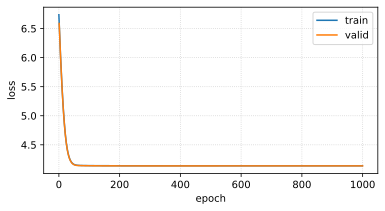

In [22]:
#| code-fold: true
plt.figure(figsize=(6, 3))
plt.plot(history["train"], label="train")
plt.plot(history["valid_steps"], history["valid"], label="valid")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend()
plt.grid(linestyle="dotted", alpha=0.6)

The model recovers the latent LF parameters better when coverage is high. Low-coverage LFs have fewer observed (non-abstain) outputs, making their confusion matrices harder to estimate:

In [23]:
from sklearn.metrics import f1_score

def estimated_f1(gen_model, j, p_classes):
    cm = gen_model.C[:, :, j].numpy()
    c = cm[:, :-1] * p_classes.reshape(-1, 1)
    precision = c[1, 1] / c[:, 1].sum()
    recall = c[1, 1] / c[1, :].sum()
    f1 = 2 * (precision * recall) / (precision + recall)
    return f1

def estimated_cov(gen_model, j, p_classes):
    cm = gen_model.C[:, :, j].numpy()
    learned_cov = cm[:, -1]
    return (1 - (learned_cov * p_classes).sum()).item()

rows = []
p_classes = np.array(list(LABEL_PROBS.values()))
for j in range(len(lf_params)):
    est_cov = estimated_cov(gen_model, j, p_classes)
    est_f1 = estimated_f1(gen_model, j, p_classes)
    mask = L_train[:, j] != ABSTAIN
    emp_f1 = f1_score(L_train[mask, j], y_train[mask]) # empirical F1

    rows.append({
        "lf":         f"LF{j+1}",
        "latent cov": lf_params[j][0],
        "est cov":    round(est_cov, 2),
        "latent F1":  round(emp_f1, 2),
        "est F1":     round(est_f1, 2),
    })
    
pd.DataFrame(rows).set_index("lf")

,latent cov,est cov,latent F1,est F1
lf,,,,
LF1,0.30,0.30,0.78,0.80
LF2,0.50,0.49,0.69,0.68
LF3,0.40,0.40,0.74,0.74
LF4,0.20,0.20,0.82,0.80
LF5,0.25,0.25,0.92,0.88


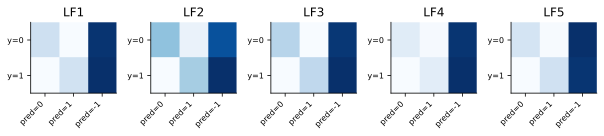

In [24]:
#| code-fold: true
from notebooks.plot import Plot

# Create a plot
p = Plot(1, len(labeling_funcs), figsize=(8.5, 2))

for j in range(len(labeling_funcs)):
    p[j].heatmap(
        torch.softmax(gen_model.C[:, :, j], dim=1),
        row_labels=["y=0", "y=1"],
        col_labels=["pred=0", "pred=1", "pred=-1"],
        cmap="Blues",
        fmt=".2f",
        colorbar=False
    )
    p[j].labels(title=f"LF{j + 1}")
p.show()

In [25]:
#| code-fold: true
frames = []
for j in range(len(lf_params)):
    C_j = gen_model.C[:, :, j]
    df = pd.DataFrame(
        C_j.numpy(),
        index=pd.MultiIndex.from_tuples([(f"LF{j+1}", f"y={k}") for k in range(K)]),
        columns=[f"pred={k}" for k in range(K)] + ["abstain"]
    )
    frames.append(df)
pd.concat(frames)

pred=0    pred=1   abstain
LF1 y=0  0.236083  0.065692  0.698226
    y=1  0.067203  0.224919  0.707878
LF2 y=0  0.325638  0.190858  0.483504
    y=1  0.166510  0.307103  0.526386
LF3 y=0  0.286827  0.117735  0.595438
    y=1  0.117591  0.274587  0.607822
LF4 y=0  0.163727  0.048506  0.787767
    y=1  0.042663  0.153281  0.804056
LF5 y=0  0.202552  0.042232  0.755216
    y=1  0.033904  0.223372  0.742724

The trained model can be used to estimate conditional probabilities of targets given LF outputs:

In [26]:
# Simple test that the model learned (without using latent labels):
l = torch.tensor([[1, 1, 1, 1, 1]])
for y in range(K):
    print(f"p(y={y} | Λ=all_pos): {gen_model.predict_proba(l)[0, y].item():.4f}")

print()
l = torch.tensor([[0, 0, 0, 0, 0]])
for y in range(K):
    print(f"p(y={y} | Λ=all_neg): {gen_model.predict_proba(l)[0, y].item():.4f}")

p(y=0 | Λ=all_pos): 0.0031
p(y=1 | Λ=all_pos): 0.9969

p(y=0 | Λ=all_neg): 0.9961
p(y=1 | Λ=all_neg): 0.0039


The conditional probabilities of targets given LF outputs sum to 1 (passes sanity check).

In [27]:
l = torch.tensor([[-1, -1, -1, -1, -1]])
for y in range(K):
    print(f"p(y={y} | Λ=all_abstain): {gen_model.predict_proba(l)[0, y].item():.4f}")

p(y=0 | Λ=all_abstain): 0.3709
p(y=1 | Λ=all_abstain): 0.6291


:::{.callout-note}
When all LFs abstain, the posterior is:

$$p(y \mid \text{all abstain}) = \frac{p_y \cdot \prod_j C^j_{y,\,K}}{\sum_{y'} p_{y'} \cdot \prod_j C^j_{y',\,K}}$$

This only equals the prior $p_y$ if $\prod_j C^j_{y,K}$ is the same for all $y$ — i.e., the joint abstention rate is class-independent. In general it's **not** exactly the prior; the abstain column of each confusion matrix can differ across rows, so even "all abstain" carries some signal about $y$.

That said, in practice abstention rates are often similar across classes (an LF fires on surface patterns, not the true label directly), so the posterior approximately collapses to the prior. And conceptually this makes sense: if no LF speaks up, the best you can do is fall back on your base rate.
:::

### Label inference (binary)

Soft labels can be generated for a test input using $p_{\hat{\Phi}}(y \mid \lambda(\textbf{\textsf{x}}))$ calculated using learned LF parameters. This already takes into account the prior label distribution. In particular, if all LFs abstain, then the model falls back roughly to the prior label distribution (see above note). Evaluating by means of ground truth labels:

In [84]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    f1_score, 
    confusion_matrix, 
    precision_score, 
    recall_score
)

def evaluate(model, x, y, t=None, verbose=True, calibrate=False, x_cal=None, class_prior: dict = None):
    if calibrate:
        class_prior = class_prior or dict()
        if x_cal is None:
            raise ValueError("calibration dataset x_cal cannot be None.")
        if t is not None:
            raise ValueError("cannot calibrate when t is not None.")
        
        # Choose threshold `t` s.t. `P(f(x) < t) = 0.4`. See appendix.
        t = torch.quantile(model.predict_proba(x_cal)[:, 1], q=class_prior.get(0, 0.5)) 

    t = t or 0.5
    m = x.shape[0]
    preds = model.predict(x, t)
    f1 = f1_score(y.numpy(), preds.numpy(), average="weighted")
    recall = recall_score(y.numpy(), preds.numpy(), average="weighted")
    precision = precision_score(y.numpy(), preds.numpy(), average="weighted")
    
    if verbose:
        print(confusion_matrix(y.numpy(), preds.numpy()))
    
    return {
        "f1": f1,
        "recall": recall,
        "precision": precision,
        "m": m, "message": f"m={m}, f1={f1:.5f}, t={t:.5f}"
    }

# Since data is imbalanced t=0.5 can be suboptimal (assuming calibrated probs)
print(evaluate(gen_model, L_train, y_train, calibrate=True, x_cal=L_train, class_prior=LABEL_PROBS)["message"]); print()
print(evaluate(gen_model, L_valid, y_valid, calibrate=True, x_cal=L_train, class_prior=LABEL_PROBS)["message"])

[[2220 1023]
 [ 946 3811]]
m=8000, f1=0.75338, t=0.62846

[[554 232]
 [220 994]]
m=2000, f1=0.77369, t=0.62846


`GenModel` integrates all five LFs and still reaches F1 ~0.78 on the synthetic validation set, which is consistent with the F1 of the LFs weighted by coverage[^lf_f1]. This is expected: rather than being bounded by the best LF, the model pools signal from all LFs. When the LFs make *conditionally independent errors*, agreement between them raises confidence and the **ensemble** can potentially push F1 above what any single LF achieves alone.

[^lf_f1]: Recall that the five simulated LFs have F1 ranging from 0.66 to 0.90, with coverages of 20–50%. In particular, LF5 has the highest F1 at 0.92, but fires on only 25% of examples. 

In [85]:
# F1 weighted by coverage
df = pd.DataFrame(rows).set_index("lf")
((df["est cov"] * df["est F1"]).sum() / df["est cov"].sum()).item()

0.7617073170731707

:::{.callout-note}
For evaluation, we will focus on F1 score for interpretability. But we can also just look at validation loss (e.g. for the multi-class setting).
:::

### Noise-aware training

Noise-aware training amounts to weighting the loss with the estimate of the generative model for each target ${p_{\hat{\Phi}}(y \mid \lambda(\textbf{\textsf{x}}))} = {p_{\hat{\Phi}}(y,\, \lambda(\textbf{\textsf{x}}))}
\, /\, {p_{\hat{\Phi}}(\lambda(\textbf{\textsf{x}}))}.$ This allows us to train a model without labels:

In [86]:
import torch.nn as nn
from tempfile import NamedTemporaryFile
np.random.seed(42); torch.manual_seed(42)


class Predictor:
    @torch.no_grad()
    def predict_proba(self, x):
        """Return class probabilities. Shape: (m, K)."""
        logits = self.clf(x)                                       # (m, K)
        return torch.softmax(logits, dim=1)

    @torch.no_grad()
    def predict(self, x, t=None):
        """Predict labels. For binary, threshold t on p(y=1) can be used."""
        probs = self.predict_proba(x)
        if t is not None and self.K == 2:
            return (probs[:, 1] >= t).long()
        return probs.argmax(dim=1)


class NoiseAwareTrainer(Predictor):
    def __init__(self, clf, gen_model):
        self.clf = clf
        self.K = gen_model.K
        self.gen_model = gen_model

    def loss_fn(self, L, x):
        with torch.no_grad():
            # p(y | Λ) for each class — shape (m, K)
            cond_probs = self.gen_model.predict_proba(L)
        logits = self.clf(x)                                       # (m, K)
        log_probs = torch.log_softmax(logits, dim=1)               # (m, K)
        return -(cond_probs * log_probs).sum(dim=1).mean()

    def run(self, x_train, x_valid, L_train, L_valid=None, epochs=10, bs=8, lr=0.001, alpha=0.0, momentum=0.1, optimizer="sgd"):
        m = x_train.shape[0]
        history = {"train": [], "valid": [], "valid_steps": []}
        best_loss = np.inf
        best_train_loss = np.inf
        best_epoch = 0
        if optimizer == "adam":
            optim = torch.optim.Adam(self.clf.parameters(), lr=lr, weight_decay=alpha)
        else:
            optim = torch.optim.SGD(self.clf.parameters(), lr=lr, weight_decay=alpha, momentum=momentum)
        
        tmp = NamedTemporaryFile(suffix=".pt", delete=True)

        try: 
            for epoch in tqdm(range(epochs)):
                B = torch.randperm(m)
                epoch_train_losses = []
                for i in range(m // bs):
                    batch = B[i * bs: (i + 1) * bs]
                    loss = self.loss_fn(L_train[batch], x_train[batch])

                    # gradient step
                    loss.backward()
                    optim.step()
                    optim.zero_grad()

                    # callbacks
                    epoch_train_losses.append(loss.item())
                    history["train"].append(loss.item())
                            
                    del loss
                    torch.cuda.empty_cache()
                
                with torch.no_grad():
                    if x_valid is not None:
                        val_loss = self.loss_fn(L_valid, x_valid)
                        history["valid"].append(val_loss.item())
                        history["valid_steps"].append((epoch + 1) * (m // bs))
                        if val_loss < best_loss:
                            best_loss = val_loss.item()
                            best_train_loss = np.mean(epoch_train_losses)
                            best_epoch = epoch
                            torch.save(self.clf.state_dict(), tmp.name)

                if epoch - best_epoch > int(0.05 * epochs):
                    print(f"Early stopping at epoch {epoch}...")
                    raise KeyboardInterrupt

        except KeyboardInterrupt:
            print("Training stopped.")

        finally:
            print(f"Best train loss: {best_train_loss:.4f} | Best valid loss: {best_loss:.4f}")
            self.clf.load_state_dict(torch.load(tmp.name, weights_only=True))
            return history


clf = nn.Sequential(nn.Linear(2, 8), nn.SELU(), nn.Linear(8, K))
trainer = NoiseAwareTrainer(clf, gen_model)
history = trainer.run(x_train, x_valid, L_train, L_valid, epochs=120, bs=32, lr=0.003, alpha=0.0, momentum=0.1)

100%|██████████| 120/120 [00:26<00:00,  4.46it/s]

Best train loss: 0.6671 | Best valid loss: 0.6634


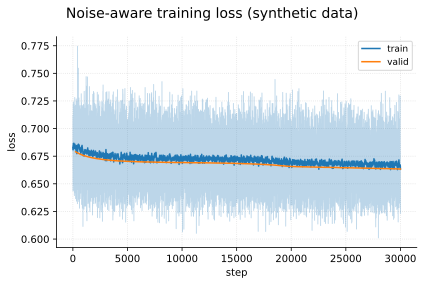

In [87]:
#| code-fold: true
from notebooks.plot import Plot

p = Plot(figsize=(6, 4), title="Noise-aware training loss (synthetic data)")
p[0].line(history["train"], color="C0", label="train", smooth=100)
p[0].line(history["valid"], x=history["valid_steps"], color="C1", label="valid")
p[0].labels(x="step", y="loss")
p.legend(loc="upper right", frameon=True)
p.show()

The model is not calibrated at the default decision threshold (`0.5`) due to imbalance:

In [88]:
print(evaluate(trainer, x_train, y_train, calibrate=True, x_cal=x_train, class_prior=LABEL_PROBS)["message"]); print()
print(evaluate(trainer, x_valid, y_valid, calibrate=True, x_cal=x_train, class_prior=LABEL_PROBS)["message"])

[[2320  923]
 [ 880 3877]]
m=8000, f1=0.77438, t=0.59133

[[ 533  253]
 [ 195 1019]]
m=2000, f1=0.77432, t=0.59133


**NOTE:** Not much better than `GenModel`. The next sections uses more a realistic dataset.

## IMDB Movie Reviews

We apply the same weak supervision pipeline to a real text classification task: **IMDB movie review sentiment analysis**. The key challenge is adapting our `GenModel` and `NoiseAwareTrainer` (designed for tensor inputs) to work with raw text data. We define text-based labeling functions that detect sentiment patterns, wrap them to be tensor-compatible, and use TF-IDF features to train the noise-aware discriminative model.

In [89]:
#| output: false
import re
import pandas as pd
from datasets import load_dataset

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# Load IMDB dataset (3000 train, 1000 valid)
ds = load_dataset("imdb")
ds_train = ds["train"].shuffle(seed=RANDOM_SEED).select(range(3000))
ds_valid = ds["test"].shuffle(seed=RANDOM_SEED).select(range(1000))

train_texts = ds_train["text"]
valid_texts = ds_valid["text"]
y_train_imdb = torch.tensor(ds_train["label"])    # {0, 1}
y_valid_imdb = torch.tensor(ds_valid["label"])

K = 2
ABSTAIN = -1

### Labeling functions

In [90]:

# (1) Strong adjectives
def lf_strong_sentiment(text):
    text = text.lower()
    pos_words = ["excellent", "masterpiece", "outstanding", "brilliant", "perfect", "superb", "fantastic", "wonderful"]
    neg_words = ["terrible", "awful", "horrible", "worst", "dreadful", "atrocious", "abysmal", "pathetic"]
    pos = any(w in text for w in pos_words)
    neg = any(w in text for w in neg_words)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN


# (2) Balance of positive/negative word counts
def lf_sentiment_words(text):
    text = text.lower()
    pos_words = ["great", "love", "amazing", "best", "enjoyed", "favorite", "fun"]
    neg_words = ["bad", "waste", "boring", "poor", "stupid", "annoying", "disappointing"]
    pos_count = sum(1 for w in pos_words if w in text)
    neg_count = sum(1 for w in neg_words if w in text)
    if pos_count > neg_count: return 1
    if neg_count > pos_count: return 0
    return ABSTAIN


# (3) Explicit ratings (e.g. "10/10", "1 star")
def lf_rating_mention(text):
    text = text.lower()
    pos_patterns = [r"10/10", r"10 out of 10", r"5 stars", r"5/5"]
    neg_patterns = [r"1/10", r"1 out of 10", r"1 star[^s]", r"0 stars", r"0/10"]
    pos = any(re.search(p, text) for p in pos_patterns)
    neg = any(re.search(p, text) for p in neg_patterns)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN


# (4) Re-watch / walk-out behavior
def lf_viewing_experience(text):
    text_lower = text.lower()
    pos_watch = ["watched twice", "seen it multiple times", "watch again", "rewatch", "couldn't stop watching"]
    neg_watch = ["walked out", "turned it off", "fell asleep", "couldn't finish", "wasted 2 hours"]
    pos = any(p in text_lower for p in pos_watch)
    neg = any(n in text_lower for n in neg_watch)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN


# (5) Negative comparative phrases
def lf_comparative_sentiment(text):
    text_lower = text.lower()
    if "worse than" in text_lower or "not as good as" in text_lower or "disappointing compared" in text_lower:
        return 0
    return ABSTAIN


# (6) Recommendation / avoidance phrases
def lf_recommendation(text):
    text = text.lower()
    pos_phrases = ["highly recommend", "must see", "must watch", "worth watching", "go see", "definitely watch", "check it out"]
    neg_phrases = ["do not recommend", "don't recommend", "avoid", "skip this", "don't bother", "don't waste", "stay away", "save your"]
    pos = any(p in text for p in pos_phrases)
    neg = any(p in text for p in neg_phrases)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN


# (7) Exclamation + sentiment phrases
def lf_exclamation_sentiment(text):
    if "!" not in text: return ABSTAIN
    text = text.lower()
    pos_phrases = ["loved it", "great film", "great movie", "must see", "highly recommended", "well done"]
    neg_phrases = ["waste of time", "don't watch", "stay away", "save your money", "never again", "so bad"]
    pos = any(p in text for p in pos_phrases)
    neg = any(p in text for p in neg_phrases)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN



# (8) Negation + positive word (likely negative review)
def lf_negated_positive(text):
    text = text.lower()
    patterns = ["not good", "not great", "not worth", "wasn't good", "wasn't great",
                "isn't good", "isn't great", "not funny", "not entertaining"]
    if any(p in text for p in patterns):
        return 0
    return ABSTAIN


# (9) Profanity / strong negative language
def lf_profanity(text):
    text = text.lower()
    words = ["crap", "crapfest", "crap fest", "crap-fest", "sucks", "crapfest"]
    if any(w in text for w in words):
        return 0
    return ABSTAIN


# (10) Emotional positive language
def lf_emotional_positive(text):
    text = text.lower()
    phrases = ["moved me", "brought me to tears", "touched my heart", "blew me away",
               "left me speechless", "changed my life", "emotional rollercoaster"]
    if any(p in text for p in phrases):
        return 1
    return ABSTAIN


# (11) Length heuristic: very short reviews tend negative
def lf_short_review(text):
    if len(text.split()) < 30:
        return 0
    return ABSTAIN


# (12) All-caps words (strong emotion, check sentiment)
def lf_allcaps_sentiment(text):
    caps_words = [w for w in text.split() if w.isupper() and len(w) > 2]
    if len(caps_words) < 2:
        return ABSTAIN
    pos = ["GREAT", "LOVE", "AMAZING", "BEST", "PERFECT", "AWESOME", "WONDERFUL"]
    neg = ["WORST", "TERRIBLE", "AWFUL", "HORRIBLE", "BAD", "HATE", "BORING"]
    pos_count = sum(1 for w in caps_words if w in pos)
    neg_count = sum(1 for w in caps_words if w in neg)
    if pos_count > neg_count: return 1
    if neg_count > pos_count: return 0
    return ABSTAIN


# (13) Director/actor praise
def lf_actor_praise(text):
    text = text.lower()
    pos = ["brilliant performance", "brilliant acting", "great performance",
           "great acting", "superb acting", "amazing performance", "stellar cast"]
    neg = ["terrible acting", "awful performance", "wooden acting",
           "bad acting", "can't act", "overacting", "miscast"]
    p = any(phrase in text for phrase in pos)
    n = any(phrase in text for phrase in neg)
    if p and not n: return 1
    if n and not p: return 0
    return ABSTAIN


# (14) Plot quality
def lf_plot_quality(text):
    text = text.lower()
    pos = ["great plot", "compelling story", "well-written", "clever plot",
           "gripping", "riveting", "page-turner", "engaging story"]
    neg = ["no plot", "plot holes", "predictable", "makes no sense",
           "incoherent", "nonsensical", "poorly written", "lazy writing"]
    p = any(phrase in text for phrase in pos)
    n = any(phrase in text for phrase in neg)
    if p and not n: return 1
    if n and not p: return 0
    return ABSTAIN


# (15) Ending sentiment
def lf_ending(text):
    text = text.lower()
    pos = ["great ending", "perfect ending", "satisfying ending", "loved the ending"]
    neg = ["terrible ending", "awful ending", "disappointing ending", "ruined the ending",
           "worst ending", "anticlimactic"]
    p = any(phrase in text for phrase in pos)
    n = any(phrase in text for phrase in neg)
    if p and not n: return 1
    if n and not p: return 0
    return ABSTAIN


# (16) Humor detection
def lf_humor(text):
    text = text.lower()
    pos = ["hilarious", "laugh out loud", "genuinely funny", "had me laughing",
           "comedy gold", "witty"]
    neg = ["not funny", "unfunny", "tries too hard", "forced humor",
           "cringe", "painfully unfunny"]
    p = any(phrase in text for phrase in pos)
    n = any(phrase in text for phrase in neg)
    if p and not n: return 1
    if n and not p: return 0
    return ABSTAIN


# (17) Repetition of negative sentiment words (>= 3 distinct)
def lf_neg_pile(text):
    text = text.lower()
    neg_words = ["bad", "terrible", "awful", "waste", "boring", "stupid",
                 "horrible", "worst", "poor", "disappointing", "dreadful"]
    count = sum(1 for w in neg_words if w in text)
    if count >= 3: return 0
    return ABSTAIN


# (18) Repetition of positive sentiment words (>= 3 distinct)
def lf_pos_pile(text):
    text = text.lower()
    pos_words = ["great", "excellent", "amazing", "love", "wonderful",
                 "brilliant", "fantastic", "superb", "best", "perfect"]
    count = sum(1 for w in pos_words if w in text)
    if count >= 3: return 1
    return ABSTAIN


# (19) Genre-specific praise (horror, thriller)
def lf_genre_tension(text):
    text = text.lower()
    pos = ["edge of my seat", "spine-tingling", "heart-pounding", "genuinely scary",
           "terrifying", "creepy atmosphere", "suspenseful"]
    neg = ["not scary", "laughable horror", "zero suspense", "predictable thriller"]
    p = any(phrase in text for phrase in pos)
    n = any(phrase in text for phrase in neg)
    if p and not n: return 1
    if n and not p: return 0
    return ABSTAIN


# (20) Sarcasm/irony indicators (negated praise patterns)
def lf_sarcasm(text):
    text = text.lower()
    patterns = ["yeah right", "oh wow", "what a masterpiece", "brilliant...",
                "great job", "sure it was good", "if you like watching paint dry"]
    # These are tricky - only fire on strong sarcasm indicators
    if any(p in text for p in ["if you like watching paint dry", "what a waste"]):
        return 0
    return ABSTAIN


text_lfs = [
    lf_strong_sentiment,       # 0
    lf_sentiment_words,        # 1
    lf_rating_mention,         # 2
    lf_viewing_experience,     # 3
    lf_comparative_sentiment,  # 4
    lf_recommendation,         # 5
    lf_exclamation_sentiment,  # 6
    lf_negated_positive,       # 7
    lf_profanity,              # 8
    lf_emotional_positive,     # 9
    lf_short_review,           # 10
    lf_allcaps_sentiment,      # 11
    lf_actor_praise,           # 12
    lf_plot_quality,           # 13
    lf_ending,                 # 14
    lf_humor,                  # 15
    lf_neg_pile,               # 16
    lf_pos_pile,               # 17
    lf_genre_tension,          # 18
    lf_sarcasm,                # 19
]

Peeking into the latent performance of the LFs:

In [91]:
# Coverage, accuracy, and F1 on train set
stats = []
for lf in text_lfs:
    outputs = [lf(t) for t in train_texts]
    labels = y_train_imdb.numpy()
    fired = [i for i, o in enumerate(outputs) if o != ABSTAIN]
    cov = len(fired) / len(outputs)
    acc = sum(1 for i in fired if outputs[i] == labels[i]) / max(len(fired), 1)
    f1 = f1_score([labels[i] for i in fired], [outputs[i] for i in fired], average="weighted") if fired else 0.0
    stats.append({
        "LF": lf.__name__,
        "coverage": f"{cov:.3f}",
        "accuracy": f"{acc:.3f}",
        "F1": f"{f1:.3f}",
    })

pd.DataFrame(stats)

,LF,coverage,accuracy,F1
0,lf_strong_sentiment,0.414,0.881,0.881
1,lf_sentiment_words,0.691,0.756,0.746
2,lf_rating_mention,0.023,0.812,0.812
3,lf_viewing_experience,0.011,0.812,0.800
4,lf_comparative_sentiment,0.013,0.800,0.711
5,lf_recommendation,0.112,0.798,0.798
6,lf_exclamation_sentiment,0.051,0.810,0.811
7,lf_negated_positive,0.028,0.845,0.774
8,lf_profanity,0.056,0.799,0.709
9,lf_emotional_positive,0.005,0.867,0.805


### Model training

**Precomputing LF outputs & features.** We apply each text LF to the raw reviews and stack the outputs into $\Lambda$ matrices, mirroring the synthetic pipeline. We also extract TF-IDF features as the input representation for the discriminative model:

In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer

def build_L_text(labeling_funcs, texts):
    """Build LF output matrix from text labeling functions."""
    return torch.tensor([[lf(t) for lf in labeling_funcs] for t in texts])

L_train_imdb = build_L_text(text_lfs, train_texts)
L_valid_imdb = build_L_text(text_lfs, valid_texts)

vec = TfidfVectorizer(max_features=5000)
vec.fit(train_texts)
x_train_imdb = torch.tensor(vec.transform(train_texts).toarray(), dtype=torch.float32)
x_valid_imdb = torch.tensor(vec.transform(valid_texts).toarray(), dtype=torch.float32)

print(f"L_train: {L_train_imdb.shape}, x_train: {x_train_imdb.shape}")
print(f"L_valid: {L_valid_imdb.shape}, x_valid: {x_valid_imdb.shape}")

L_train: torch.Size([3000, 20]), x_train: torch.Size([3000, 5000])
L_valid: torch.Size([1000, 20]), x_valid: torch.Size([1000, 5000])


**Generative model.** We train `GenModel` on the text LF outputs with a balanced prior. The model learns the latent confusion matrix of each LF and produces soft labels $p_{\hat{\Phi}}(y \mid \lambda(\textbf{\textsf{x}}_i))$ for every review:

In [93]:
IMDB_LABEL_PROBS = {0: 0.50, 1: 0.50}

gen_model_imdb = GenModel(num_classes=2, num_lfs=len(text_lfs), class_prior=IMDB_LABEL_PROBS)
history_gen_imdb = gen_model_imdb.fit(L_train_imdb, L_valid_imdb, epochs=1000, lr=0.03)

100%|██████████| 1000/1000 [00:08<00:00, 119.24it/s]


Training and validation NLL for the generative model:

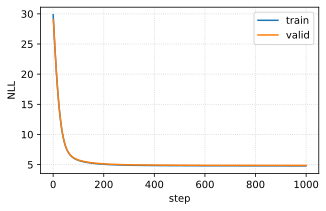

In [94]:
#| code-fold: true
plt.figure(figsize=(5, 3))
plt.plot(history_gen_imdb["train"], label="train")
plt.plot(history_gen_imdb["valid_steps"], history_gen_imdb["valid"], label="valid")
plt.legend()
plt.xlabel("step")
plt.ylabel("NLL")
plt.grid(linestyle="dotted", alpha=0.6);

**Noise-aware training.** We train an MLP on TF-IDF features using the noise-aware loss, weighted by the generative model's soft labels. The discriminative model can generalize beyond the keywords used in the LFs by leveraging the full TF-IDF vocabulary:

In [76]:
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

clf_imdb = nn.Sequential(
    nn.Linear(5000, 32), 
    nn.SELU(), 
    nn.Linear(32, K)
)

trainer_imdb = NoiseAwareTrainer(clf_imdb, gen_model_imdb)
history_nat_imdb = trainer_imdb.run(
    x_train_imdb, x_valid_imdb, L_train_imdb, L_valid_imdb,
    epochs=300, bs=64, lr=0.003, alpha=0.0, momentum=0.9,
)

 57%|█████▋    | 171/300 [00:12<00:09, 13.19it/s]

Early stopping at epoch 171...
Training stopped.
Best train loss: 0.3656 | Best valid loss: 0.4563


Training and validation loss for the noise-aware discriminative model:

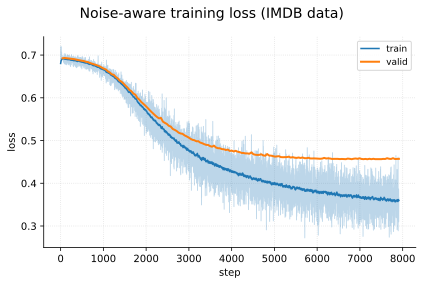

In [77]:
#| code-fold: true
from notebooks.plot import Plot

p = Plot(figsize=(6, 4), title="Noise-aware training loss (IMDB data)")
p[0].line(history_nat_imdb["train"], color="C0", label="train", smooth=100)
p[0].line(history_nat_imdb["valid"], x=history_nat_imdb["valid_steps"], color="C1", label="valid", lw=2)
p[0].labels(x="step", y="loss")
p.legend(loc="upper right", frameon=True)
p.show()

### Evaluation

In [95]:
print("GenModel (IMDB):")
print(evaluate(gen_model_imdb, L_train_imdb, y_train_imdb, calibrate=True, x_cal=L_train_imdb, class_prior=IMDB_LABEL_PROBS)["message"]); print()
print(evaluate(gen_model_imdb, L_valid_imdb, y_valid_imdb, calibrate=True, x_cal=L_train_imdb, class_prior=IMDB_LABEL_PROBS)["message"])

print("\nNoiseAwareTrainer (IMDB):")
print(evaluate(trainer_imdb, x_train_imdb, y_train_imdb, calibrate=True, x_cal=x_train_imdb, class_prior=IMDB_LABEL_PROBS)["message"]); print()
print(evaluate(trainer_imdb, x_valid_imdb, y_valid_imdb, calibrate=True, x_cal=x_train_imdb, class_prior=IMDB_LABEL_PROBS)["message"])

GenModel (IMDB):
[[ 972  536]
 [ 170 1322]]
m=3000, f1=0.76127, t=0.51019

[[363 144]
 [ 60 433]]
m=1000, f1=0.79479, t=0.51019

NoiseAwareTrainer (IMDB):
[[1211  297]
 [ 289 1203]]
m=3000, f1=0.80467, t=0.55754

[[426  81]
 [ 97 396]]
m=1000, f1=0.82191, t=0.55754


Unlike in the toy dataset, the NAT model outperforms `GenModel` on IMDB reviews. While the generative model can only make predictions from "finite" LF output patterns, the discriminative model leverages [TF-IDF feature vectors]{.mark} to capture sentiment signals beyond the heuristics hardcoded in the LFs. This turns out to matter for a real dataset.

## Self-training on pseudo-labels

Our goal is to push the discriminative model further. We try three changes simultaneously: [more training data]{.underline} (3k → 6k reviews), [richer features]{.underline} (bigram TF-IDF) + more complex model, and [**self-training** on pseudo-labeled data]{.mark}. Rather than guessing which axis matters most, we apply all three and use ablations to decompose the gains.

**Data.** For ablations, we expand the training set from 3000 to 6000 reviews and switch to bigram TF-IDF (`ngram_range=(1, 2)`, 7000 features), which captures multi-word phrases like "waste of time" or "must watch" that unigram TF-IDF misses. The original generative model (trained on 3000 reviews) is reused to produce soft labels for all 6000 points[^gen_model_retraining]. Note that we keep the [same validation set]{.mark} (i.e. the same reviews) to ensure the comparisons are valid.

[^gen_model_retraining]: Retraining `GenModel` on the larger set actually hurts performance, since the additional data dilutes the LF statistics the model was optimized on.

In [79]:
#| output: false
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

# Larger training set: 6000 reviews
ds_train_v2 = ds["train"].shuffle(seed=RANDOM_SEED).select(range(6000))
train_texts_v2 = ds_train_v2["text"]

# Recompute LF outputs on the larger training set, get labels for validation
y_train_v2 = torch.tensor(ds_train_v2["label"])
L_train_v2 = build_L_text(text_lfs, train_texts_v2)

# Reuse the original generative model — retraining on 6k hurts performance
# Bigram TF-IDF with 7k features w/ sublinear scaling of TF: i.e. 1 + log(TF)
vec_v2 = TfidfVectorizer(max_features=7000, ngram_range=(1, 2), sublinear_tf=True)
vec_v2.fit(train_texts_v2)
x_valid_v2 = torch.tensor(vec_v2.transform(valid_texts).toarray(), dtype=torch.float32)
x_train_v2 = torch.tensor(vec_v2.transform(train_texts_v2).toarray(), dtype=torch.float32)

print(f"L_train_v2: {L_train_v2.shape}")
print(f"x_train_v2: {x_train_v2.shape}")
print(f"x_valid_v2: {x_valid_v2.shape}")

L_train_v2: torch.Size([6000, 20])
x_train_v2: torch.Size([6000, 7000])
x_valid_v2: torch.Size([1000, 7000])


**Model.** The baseline MLP uses a single hidden layer of 32 units — a bottleneck with 5000 input features. We widen the teacher to two hidden layers (128 and 32 units) and add L2 regularization (`weight_decay=1e-4`) to prevent overfitting on noisy soft labels:

In [96]:
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

clf_v2 = nn.Sequential(
    nn.Linear(7000, 128), nn.SELU(),
    nn.Linear(128, 32), nn.SELU(),
    nn.Linear(32, K),
)

trainer_v2 = NoiseAwareTrainer(clf_v2, gen_model_imdb)  # <1>
history_v2 = trainer_v2.run(
    x_train_v2, x_valid_v2, L_train_v2, L_valid_imdb,
    epochs=300, bs=64, lr=0.003, alpha=1e-4, momentum=0.9,
)

print()
print("\nNAT v2 (IMDB, valid):")
print(evaluate(trainer_v2, x_valid_v2, y_valid_imdb, calibrate=True, x_cal=x_train_v2, class_prior=IMDB_LABEL_PROBS)["message"])

 16%|█▌        | 48/300 [00:29<02:34,  1.63it/s]

Early stopping at epoch 48...
Training stopped.
Best train loss: 0.3607 | Best valid loss: 0.4310


NAT v2 (IMDB, valid):


[[429  78]
 [ 97 396]]
m=1000, f1=0.82489, t=0.57145


1. The original generative model (trained on 3k) is reused as-is. Its confusion matrices already capture the LF statistics well; applying them to the 6k training set requires only forward inference.

In [ ]:
print(evaluate(trainer_v2, x_valid_v2, y_valid_imdb, calibrate=True, x_cal=x_train_v2, class_prior=IMDB_LABEL_PROBS)["message"])

[[407 100]
 [ 74 419]]
m=1000, f1=0.82595, t=0.50000


:::{.callout-note}
NAT v2 achieves F1 = 0.826 — a marginal +0.1pp over the baseline. The richer features and more data alone barely move the needle. The payoff comes in the next step. Below it will be shown that NAT v2 produces more pseudo-labeled examples than the baseline NAT.
:::

### Getting pseudo-labels

**Pseudo-labeling.** We apply NAT v2 to 10,000 held-out reviews (indices 6000–16000, disjoint from training and validation) and retain predictions with $\max_y\, p(y \mid \textbf{\textsf{x}}) \geq 0.85$ as pseudo-labels. We also record oracle accuracy — the fraction of pseudo-labels that match the true IMDB labels — as a proxy for pseudo-label quality:

In [46]:
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

# Unlabeled pool: 10k reviews disjoint from train/valid
ds_pool = ds["train"].shuffle(seed=RANDOM_SEED).select(range(6000, 16000))
y_pool = torch.tensor(ds_pool["label"])  # Only for evaluation, not used in training
x_pool = torch.tensor(vec_v2.transform(ds_pool["text"]).toarray(), dtype=torch.float32)

# Get confident pseudo-labels
probs_pool = trainer_v2.predict_proba(x_pool)  # (10000, 2)
confidence, pseudo_labels = probs_pool.max(dim=1)

CONF_THRESHOLD = 0.85
confident_mask = confidence >= CONF_THRESHOLD
n_confident = confident_mask.sum().item()
pseudo_acc = (pseudo_labels[confident_mask] == y_pool[confident_mask]).float().mean()

print(f"Confident predictions: {n_confident}/{len(confident_mask)} ({n_confident/len(confident_mask):.1%})")
print(f"Pseudo-label accuracy (oracle check): {pseudo_acc:.3f}")

Confident predictions: 4822/10000 (48.2%)
Pseudo-label accuracy (oracle check): 0.947


NAT v2 labels **48.2%** of the pool at 94.7% oracle accuracy. As an exercise, you can show that the baseline NAT labels 39.6% at 95.8% accuracy. The stronger teacher produces ~900 more pseudo-labeled examples but at a slightly lower per-example accuracy. Later we see will that the net effect of the extra data outweighs the additional noise.

### Hard label training

We combine (1) [the original 6000 weakly-supervised examples]{.mark} with (2) [the confident pseudo-labeled pool]{.mark}. The original soft labels are [converted to hard labels]{.underline} (argmax of the generative model posterior) so the combined dataset uses a single cross-entropy objective:

In [47]:
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Hard labels from generative model for original training set
y_train_v2_gen = gen_model_imdb.predict_proba(L_train_v2).argmax(dim=1)

# Combine original + confident pseudo-labeled data
x_combined = torch.cat([x_train_v2, x_pool[confident_mask]], dim=0)
y_combined = torch.cat([y_train_v2_gen, pseudo_labels[confident_mask]], dim=0)

print(f"Combined training set: {x_combined.shape[0]} examples")
print(f"  Hard labels from gen model: {x_train_v2.shape[0]}")
print(f"  Pseudo-labeled (confident): {confident_mask.sum().item()}")

Combined training set: 10822 examples
  Hard labels from gen model: 6000
  Pseudo-labeled (confident): 4822


### Pseudo-label trainer

For clarity, we refactor everything into a class:

In [48]:
import torch.nn as nn
import torch.nn.functional as F
from tempfile import NamedTemporaryFile
np.random.seed(42); torch.manual_seed(42)


def supervised_training_loop(
    clf, 
    x_train, y_train, 
    x_valid, y_valid,
    epochs=300, bs=64, lr=0.003, alpha=1e-4, momentum=0.9,
    optimizer="sgd"
):
    """Standard supervised training with cross-entropy loss."""
    m = x_train.shape[0]
    loss_fn = F.cross_entropy
    best_loss, best_epoch = np.inf, 0
    history = {"train": [], "valid": [], "valid_steps": []}
    tmp = NamedTemporaryFile(suffix=".pt", delete=True)
    if optimizer == "adam":
        optim = torch.optim.Adam(clf.parameters(), lr=lr, weight_decay=alpha)
    else:
        optim = torch.optim.SGD(clf.parameters(), lr=lr, weight_decay=alpha, momentum=momentum)

    try:
        for epoch in tqdm(range(epochs)):
            B = torch.randperm(m)
            epoch_train_losses = []
            for i in range(m // bs):
                batch = B[i * bs: (i + 1) * bs]
                loss = loss_fn(clf(x_train[batch]), y_train[batch])
                loss.backward()
                optim.step()
                optim.zero_grad()
                epoch_train_losses.append(loss.item())
                history["train"].append(loss.item())

            with torch.no_grad():
                val_loss = loss_fn(clf(x_valid), y_valid)
                history["valid"].append(val_loss.item())
                history["valid_steps"].append((epoch + 1) * (m // bs))
                if val_loss < best_loss:
                    best_loss = val_loss.item()
                    best_train_loss = np.mean(epoch_train_losses)
                    best_epoch = epoch
                    torch.save(clf.state_dict(), tmp.name)

            if epoch - best_epoch > int(0.05 * epochs):
                print(f"Early stopping at epoch {epoch}...")
                raise KeyboardInterrupt

    except KeyboardInterrupt:
        print("Training stopped.")
    finally:
        print(f"Best train loss: {best_train_loss:.4f} | Best valid loss: {best_loss:.4f}")
        clf.load_state_dict(torch.load(tmp.name, weights_only=True))
        return history


class PseudoLabelSelfTrainer(Predictor):
    def __init__(self, clf, gen_model, nat_model, conf_threshold=0.85):
        self.clf = clf
        self.K = gen_model.K
        self.gen_model = gen_model
        self.nat_model = nat_model
        self.conf_threshold = conf_threshold

    def build_pseudo_labels(self, x_pool):
        probs_pool = torch.softmax(self.nat_model(x_pool), dim=1)
        confidence, pseudo_labels = probs_pool.max(dim=1)
        mask = confidence >= self.conf_threshold
        return mask, pseudo_labels

    def build_gen_labels(self, L):
        return self.gen_model.predict_proba(L).argmax(dim=1)

    def build_train_dataset(self, x_train, x_pool, L_train):
        # Convert soft-labels to hard-labels for this run
        y_train_gen = self.build_gen_labels(L_train)

        # Combine original + confident pseudo-labeled data
        M, y_pool_pseudo = self.build_pseudo_labels(x_pool)
        x_combined = torch.cat([x_train, x_pool[M]], dim=0)
        y_combined = torch.cat([y_train_gen, y_pool_pseudo[M]], dim=0)
        return x_combined, y_combined

    def run(self, x_train, x_valid, x_pool, L_train, L_valid, epochs=10, bs=8, lr=0.001, alpha=0.0, momentum=0.1, optimizer="sgd"):
        y_valid_gen = self.build_gen_labels(L_valid)
        x_train_combined, y_train_combined = self.build_train_dataset(x_train, x_pool, L_train)
        return supervised_training_loop(
            self.clf, 
            x_train_combined, y_train_combined, 
            x_valid, y_valid_gen,
            epochs=epochs, bs=bs, lr=lr, alpha=alpha, momentum=momentum,
            optimizer=optimizer
        )


clf_self = nn.Sequential(
    nn.Linear(7000, 128), nn.SELU(),
    nn.Linear(128, 32), nn.SELU(),
    nn.Linear(32, K),
)

self_trainer = PseudoLabelSelfTrainer(clf_self, gen_model_imdb, nat_model=trainer_v2.clf)
self_history = self_trainer.run(
    x_train_v2, x_valid_v2, x_pool, 
    L_train_v2, L_valid_imdb, 
    epochs=300, bs=64, lr=0.003, alpha=1e-4, momentum=0.9
)

  9%|▉         | 27/300 [00:20<03:32,  1.29it/s]

Early stopping at epoch 27...
Training stopped.
Best train loss: 0.1326 | Best valid loss: 0.3394


:::{.callout-note}
Note that we likewise converted soft validation labels from `GenModel` to hard labels for consistency. 
The entire pipeline from the generative model to NAT trainer to self-training require no ground truth labels.
This can be seen by tracking the call inputs: 

```python
gen_model_imdb.fit(L_train_imdb, L_valid_imdb, ...)
trainer_v2.run(x_train_v2, x_valid_v2, L_train_v2, L_valid_imdb, ...)
self_trainer.run(x_train_v2, x_valid_v2, x_pool, L_train_v2, L_valid_imdb, ...)
```
:::

In [97]:
# Wrap self-trained model for evaluate() compatibility
print("Self-trained model (valid):")
print(
    evaluate(
        self_trainer, x_valid_v2, y_valid_imdb, 
        calibrate=True, x_cal=x_train_v2, class_prior=IMDB_LABEL_PROBS
    )["message"]
)

Self-trained model (valid):
[[445  62]
 [104 389]]
m=1000, f1=0.83361, t=0.84107


:::{.callout-note}
The motivation for having a [second model (*student*)]{.underline} is that the [NAT model (*teacher*)]{.mark} has learned to generalize beyond LF patterns. Because it operates on raw TF-IDF features rather than LF output vectors, it can assign confident predictions on examples where the labeling functions abstain or disagree — precisely the points where the generative model's signal is weakest. Incorporating those confident predictions as additional training examples provides supervision that the generative model alone cannot supply.
:::

### Some ablations

To separate the effect of self-training from the NAT v2 improvements, we repeat the procedure with the original baseline NAT as teacher — unigram TF-IDF (5k), 3000 training examples, same `[32]` architecture — on a disjoint pool starting at index 3000. The student also uses unigram features, so only the pseudo-labeling step changes:

In [ ]:
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

clf_self_abl = nn.Sequential(
    nn.Linear(5000, 32), nn.SELU(),
    nn.Linear(32, K)
)

x_pool_v1 = torch.tensor(vec.transform(ds_pool["text"]).toarray(), dtype=torch.float32)
self_trainer_abl = PseudoLabelSelfTrainer(clf_self_abl, gen_model_imdb, nat_model=trainer_imdb.clf)
self_history_abl = self_trainer_abl.run(
    x_train_imdb, x_valid_imdb, x_pool_v1, 
    L_train_imdb, L_valid_imdb, 
    epochs=300, bs=64, lr=0.003, alpha=1e-4, momentum=0.9
)

print("\nAblation — NAT baseline + pseudo (valid):")
t_best = calibrate_threshold(self_trainer_abl, torch.cat([x_train_imdb, x_valid_imdb]))
print(evaluate(self_trainer_abl, x_valid_imdb, y_valid_imdb, t=t_best)["message"])

 21%|██▏       | 64/300 [00:05<00:21, 10.85it/s]

Early stopping at epoch 64...
Training stopped.
Best train loss: 0.1015 | Best valid loss: 0.3698

Ablation — NAT baseline + pseudo (valid):
[[380 127]
 [ 39 454]]
m=1000, f1=0.83291, t=0.55613


In [ ]:
t_best = calibrate_threshold(trainer_imdb, torch.cat([x_train_imdb, x_valid_imdb]))
print(evaluate(trainer_imdb, x_valid_imdb, y_valid_imdb, t=t_best)["message"])

[[365 142]
 [ 46 447]]
m=1000, f1=0.81051, t=0.41017


## Supervised fine-tuning

**Supervised fine-tuning.** The 200 labeled examples used for threshold calibration are enough to fine-tune the self-trained model. Rather than discarding them after threshold selection, we run a few additional epochs of standard cross-entropy on top of `clf_st` — the weights are already well-initialized from self-training, so even a small labeled signal can correct residual errors near the decision boundary:

In [ ]:
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

# 200 labeled examples already used for threshold calibration
x_labeled = x_valid_v2[:200]       # use same vec_v2 features as self-trained model  # <1>
y_labeled = y_valid_imdb[:200]
x_ft_val  = x_valid_v2[200:]
y_ft_val  = y_valid_imdb[200:]

import copy
clf_ft = copy.deepcopy(clf_st)      # start from self-trained weights, not scratch  # <2>

history_ft = train_supervised(
    clf_ft, x_labeled, y_labeled, x_ft_val, y_ft_val,
    epochs=300, bs=32, lr=1e-3, alpha=1e-3, momentum=0.9,
)

trainer_ft = SelfTrainedWrapper(clf_ft, K)
print("Fine-tuned model (full valid):")
print(evaluate(trainer_ft, x_valid_v2, y_valid_imdb, t=0.5)["message"])

 15%|█▌        | 45/300 [00:01<00:08, 30.73it/s]

Early stopping at epoch 45...
Training stopped.
Best valid loss: 0.3327
Fine-tuned model (full valid):
[[441  66]
 [ 39 454]]
m=1000, f1=0.89496, t=0.50000


1. `x_valid_v2` uses the bigram TF-IDF vectorizer from NAT v2 — the same feature space the self-trained model was trained on.
2. Fine-tuning from `clf_st` weights rather than random initialization is critical: the model already understands the task, so the 200 labels only need to nudge the decision boundary, not learn representations from scratch.

**Ablation: supervised from scratch.** To confirm that the fine-tuning gain comes from the weak supervision initialization rather than the 200 labels alone, we train the same architecture from random weights using only the 200 labeled examples:

In [ ]:
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

clf_scratch = nn.Sequential(
    nn.Linear(7000, 128),
    nn.SELU(),
    nn.Linear(128, 32),
    nn.SELU(),
    nn.Linear(32, K),
)

history_scratch = train_supervised(
    clf_scratch, x_labeled, y_labeled, x_ft_val, y_ft_val,
    epochs=300, bs=32, lr=1e-3, alpha=1e-3, momentum=0.9,
)

trainer_scratch = SelfTrainedWrapper(clf_scratch, K)
print("From scratch — 200 labels only (full valid):")
print(evaluate(trainer_scratch, x_valid_v2, y_valid_imdb, t=0.5)["message"])

 10%|█         | 30/300 [00:03<00:28,  9.54it/s]


Early stopping at epoch 30...
Training stopped.
Best valid loss: 0.6928
From scratch — 200 labels only (full valid):
[[507   0]
 [493   0]]
m=1000, f1=0.34114, t=0.50000


### Results Summary

Comparing all variants on the IMDB validation set (1000 reviews):

| Model | Features | Train Size | Train Loss | Valid Loss | Valid F1 | $\Delta$ |
| :-- | :-: | :-: | :-: | :-: | :-: | :-: |
| GenModel (baseline) | LF outputs | 3000 | — | — | 0.794 | — |
| NAT (baseline) | unigram TF-IDF (5k) | 3000 | — | — | 0.823 | — |
| NAT v2 (teacher only) | bigram TF-IDF (7k) | 6000 | — | — | 0.824 | +0.1 |
| NAT baseline + self-training | unigram TF-IDF (5k) | 3000 + pseudo | — | — | 0.829 | +0.6 |
| NAT v2 + self-training | bigram TF-IDF (7k) | 6000 + pseudo | — | — | 0.852 | +2.9 |
| + fine-tuning (200 labels) | bigram TF-IDF (7k) | 6000 + pseudo + 200 | — | — | **0.895** | **+7.2** |
| CE from scratch (200 labels) | bigram TF-IDF (7k) | 200 | — | — | 0.341 | −48.2 |

: {tbl-colwidths="[28,20,18,10,10,10,10]"}

The results form a $2 \times 2$ pattern. Improving the teacher alone (NAT v2) gives +0.1pp. Applying self-training with the weaker baseline teacher gives +0.6pp. The combination gives +2.9pp — well above the sum of the individual gains. Fine-tuning the self-trained model on just 200 labeled examples adds a further **+4.3pp**, reaching F1 = 0.895. The from-scratch baseline collapses to F1 = 0.341 — the same 200 labels are useless without the weak supervision initialization. [A 7000-feature MLP has far too many parameters to learn from 200 examples; the weak supervision pipeline provides the dense, task-relevant initialization that makes every label count.]{.mark}

---

$\blacksquare$

## Appendix: Threshold tuning

For binary problems, we consider two ways to improve the threshold `t` with little or no data:

**1. Matching the label prior distribution.** The threshold for predicting hard labels can be calibrated by using the prior label distribution. Let $\pi = p_1.$ We want:
$\textrm{P}(f(x) \geq t)=\pi$ which implies 
$\textrm{P}(f(x)<t)=1-\pi.$ This is exactly what a $q$-quantile gives: the value below which fraction $q$ of data lies. So:

$$
t= \text{ quantile at } (1-\pi).
$$ 

Here we use the entirety of our data (i.e. `x`) to estimate the threshold:

In [ ]:
def calibrate_threshold(trainer, data, class_prior: dict = LABEL_PROBS):
    probs = trainer.predict_proba(data)[:, 1]
    return np.quantile(probs, 1 - class_prior[1])

t_calibrated = calibrate_threshold(trainer, data=x_train)
print(evaluate(trainer, x_train, y_train, t=t_calibrated)["message"]); print()
print(evaluate(trainer, x_valid, y_valid, t=t_calibrated)["message"])

[[2325  918]
 [ 875 3882]]
m=8000, f1=0.77563, t=0.59130

[[ 535  251]
 [ 195 1019]]
m=2000, f1=0.77539, t=0.59130


:::{.callout-note}
This calibration uses only the [train dataset]{.mark} and assumes exact [knowledge of the class prior]{.mark}. The cross-entropy objective selects the threshold $t$ whose predicted label distribution best matches the prior. If the label prior estimate is inaccurate, the selected [decision threshold]{.underline} shifts accordingly: overestimating $p_1$ pushes $t$ lower (more positive preds), while underestimating it pushes $t$ higher (more negative preds)[^class_prior_estimation]. 
:::

[^class_prior_estimation]: In practice, the class prior is rarely known exactly, so this approach is sensitive to estimation error &mdash; especially for imbalanced problems.

**2. Threshold tuning on a small labeled subset.** If a representative subset of the data is labeled, even if small, then we can use that to tune the threshold. The following iteratively finds the threshold that maximizes weighted F1 on the validation set:

[[3134   68]
 [1142 3556]]
m=7900, f1=0.84795, t=0.59660

[[774  12]
 [276 938]]
m=2000, f1=0.85757, t=0.59660


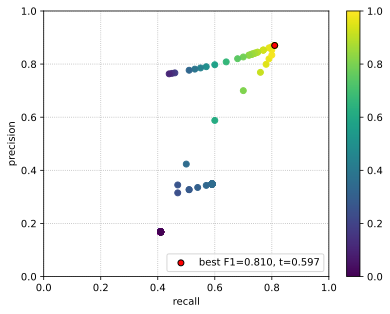

In [ ]:
def pr_curve(model, x, y, num_thresholds, min_t=0.0, max_t=1.0):
    p, r, t, f = [], [], [], []
    for threshold in np.linspace(min_t, max_t, num_thresholds):
        preds = model.predict(x, threshold).numpy()
        f.append(f1_score(y.numpy(), preds, average="weighted"))
        r.append(recall_score(y.numpy(), preds, average="weighted"))
        p.append(precision_score(y.numpy(), preds, average="weighted"))
        t.append(threshold)
    
    return p, r, t, f

def tune_pr_curve(model, x, y, num_thresholds=200, min_t=0.0, max_t=1.0, plot=True):
    """Tune threshold based on validation set."""
    p, r, t, f = pr_curve(model, x, y, num_thresholds, min_t, max_t);
    t_best_idx = np.argmax(f)
    t_best = t[t_best_idx]

    if plot:
        plt.grid(linestyle="dotted", zorder=0)
        plt.scatter(r, p, c=f, zorder=2)
        plt.scatter(x=r[t_best_idx], y=p[t_best_idx], edgecolor="k", facecolor="red", label=f"best F1={f[t_best_idx]:.3f}, t={t_best:.3f}", zorder=3)
        plt.colorbar()
        plt.xlabel("recall")
        plt.ylabel("precision")
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.legend(loc="lower right")

    return t_best


# Tuning the threshold on a labeled subset (here 100 pts)
t_best = tune_pr_curve(trainer, x_train[:100], y_train[:100], num_thresholds=1000, min_t=0.0, max_t=1.0)
print(evaluate(trainer, x_train[100:], y_train[100:], t=t_best)["message"]); print()
print(evaluate(trainer, x_valid, y_valid, t=t_best)["message"])

## Appendix: (Not) Learning the Class Prior


:::{.callout-caution}
**Learning the prior from LF votes is unreliable.** Unless the LFs are approximately symmetric across classes — similar coverage and accuracy for both classes — the learned prior will reflect LF vote skew rather than the true class balance. This is an unrealistic constraint in practice: LF developers naturally write rules that fire on the most discriminative signal, not rules that balance class counts. Treat this approach as an instructive exercise in extending `GenModel`, not a production recommendation.
:::

Throughout the notebook we treated the class prior $p_y$ as a fixed input. In practice, the true class balance is rarely known. One fix is to make $p_y$ a **learnable parameter** and optimize it along with the confusion matrices via MLE. The only change required is in `GenModel.fit` where we introduce a logit vector $\boldsymbol{\alpha} \in \mathbb{R}^K$ and compute $p_y = \text{softmax}(\boldsymbol{\alpha})_y$ at each step:

```python
prior_logits = torch.nn.Parameter(torch.zeros(self.K))   # uniform init
optimizer = torch.optim.Adam([logits, prior_logits], lr=lr)

# Then inside the training loop:
self.py = torch.softmax(prior_logits, dim=0)
```

**NOTE:** The rest of the model (`loss_fn`, `_build_C`, `predict`) remains unchanged because they already reference `self.py`.

The intuition is that LF agreement patterns carry information about the class balance: if LFs vote positive more often, the marginal likelihood is higher under a prior that skews positive, so gradient descent will push $\boldsymbol{\alpha}$ in that direction. However, [this is also the failure mode]{.mark}. If the LFs themselves are asymmetric across classes (higher coverage or accuracy for one class), the learned prior absorbs LF bias rather than the true class balance. 

We ran this experiment[^params] and obtained the following results:

| Experiment | True prior | Learned prior | Fixed-prior F1 | Learned-prior F1 |
| :-- | :-: | :-: | :-: | :-: |
| Synthetic | 0.40 / 0.60 | 0.37 / 0.63 | 0.777 | 0.777 |
| IMDB | 0.50 / 0.50 | [0.31 / 0.69]{.mark} | 0.770 | [0.712]{.mark} |

<br>

On synthetic data, the learned prior is close to ground truth, and [F1 is comparable]{.underline}. On IMDB, `lf_sentiment_words` correctly labels 875 positives but only 485 negatives, so the MLE prior absorbs the LF skew and [F1 drops by several points]{.underline}. The root cause is an identifiability problem: the marginal likelihood $p(\Lambda) = \sum_y p_y \prod_j C^j_{y,\lambda_j}$ cannot distinguish LF bias from true class imbalance: $C^j_{y,\lambda_j} = p_\Phi(\lambda_j \mid y)$ is conditioned on $y$ &mdash; so it doesn't care about $p_y$, while $p_y$ is incentivized to amplify LF bias to maximize $p(\Lambda)$. 

Indeed, dropping `lf_sentiment_words` does not recover 0.50; it collapses the prior to the opposite extreme (0.999/0.001) because the remaining LFs are collectively negative-biased. A single dominant LF can flip the learned prior entirely.

[^params]: Same params `epochs=5000`, `lr=0.01` and datasets `L_train_imdb`, `L_valid_imdb`.

:::{.callout-tip}
A **small labeled sample** is a more robust alternative to learning the prior from LF votes. As shown above, the learned prior is unreliable unless LFs are symmetric across classes — a constraint that conflicts with how LFs are naturally developed. Even 50–100 labels can beat a badly learned prior, as the CI analysis below shows.
In general, getting more samples help to reduce CI width at the rate $O(1/{\sqrt{n}}).$ More details below.

**How many labels do you need?** Suppose you hand-label $n$ examples and find that a fraction $\hat{p}$ of them are positive. Then, the 95% [confidence interval](https://en.wikipedia.org/wiki/Confidence_interval#/media/File:Normal_distribution_50%25_CI_illustration.svg)[^ci] (CI) for the true positive fraction $p$ is approximately $\hat{p} \pm 1.96\sqrt{\hat{p}(1-\hat{p})/n}.$ The interval is widest when $\hat{p} = 0.5$ (balanced classes), which gives an upper bound on how imprecise your estimate can be:

| Labeled samples $n$ | 95% CI half-width | Example: $\hat{p} = 0.50$ |
|:--:|:--:|:--|
| 30 | $\pm$ 0.18 | [0.32, 0.68] |
| 50 | $\pm$ 0.14 | [0.36, 0.64] |
| 100 | $\pm$ 0.10 | [0.40, 0.60] |
| 200 | $\pm$ 0.07 | [0.43, 0.57] |
| 500 | $\pm$ 0.04 | [0.46, 0.54] |

So 50–100 labels give you roughly $\pm 0.10$–$0.14$ precision on the prior. Whether that's good enough depends on how wrong the alternative is. In our IMDB case the learned prior was off by 0.19 (0.31 vs. 0.50), so even 50 labeled examples would likely beat it. But if the LFs were only slightly biased, a noisy 50-sample estimate could be worse.
:::

[^ci]: A 95% confidence interval means that if you repeated this sampling-and-estimation procedure many times, about 95% of the resulting intervals would contain the true parameter. <br><br>Operationally, if you collect 100 labeled samples and compute the interval, you can act as if the true prior lies within it — accepting a 1-in-20 chance of being wrong. Note that the prior affects both training and inference, so errors compound: if your LFs are already somewhat positive-biased, an overestimated prior amplifies that bias further through training, then again at inference.